# LR 13

# Упражнения

1. Запишите два разных звука 
1. Вычислить их спектральные характеристики (спектр, MFCC, GFCC) 
1. Построение спектрограммы 
1. Проанализируйте их сходства и различия

## Импорт библиотек и начальные настройки

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy.io import wavfile
from scipy import signal
from scipy.fft import fft, fftfreq, rfft, rfftfreq, irfft
from scipy.fft import dct
from pydub import AudioSegment
import librosa
import librosa.display
from python_speech_features import mfcc as psf_mfcc
from python_speech_features import logfbank
import warnings
warnings.filterwarnings('ignore')

np.random.seed(0)

# Пути к файлам (файлы должны лежать рядом с ноутбуком)
FILE1 = 'sound1.wav'
FILE2 = 'sound2.wav'


In [3]:
def plot_waveform(time, data, title, ax, color='tab:blue'): # Визуализация временного сигнала
    ax.plot(time, data, color=color, lw=0.7)
    ax.set_xlabel('Время (с)', fontsize=11)
    ax.set_ylabel('Амплитуда', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.grid(alpha=0.3)

def load_wav(filepath): 
    samplerate, data = wavfile.read(filepath)
    if data.ndim > 1:
        data = data[:, 0]
    duration = len(data) / samplerate
    time = np.arange(0, duration, 1 / samplerate)[:len(data)]
    return samplerate, data, duration, time

def to_mono_pydub(filepath, out_path):
    # Конвертация стерео в моно через pydub
    seg = AudioSegment.from_wav(filepath)
    seg = seg.set_channels(1)
    seg.export(out_path, format='wav')
    sr, data = wavfile.read(out_path)
    return sr, data

def compute_spectrum(data, samplerate):
    # FFT (полный спектр, симметричный)
    N = len(data)
    yf = fft(data.astype(float))
    xf = fftfreq(N, 1 / samplerate)
    return xf, yf

def compute_rspectrum(data, samplerate):
    # RFFT (односторонний спектр)
    N = len(data)
    ryf = rfft(data.astype(float))
    rxf = rfftfreq(N, 1 / samplerate)
    return rxf, ryf

def compute_cepstrum(data, samplerate):
    # Кепстр: IFFT(log|FFT(x)|)
    N = len(data)
    yf = np.abs(fft(data.astype(float)))
    yf[yf == 0] = 1e-10
    log_spectrum = np.log(yf)
    cepstrum = np.abs(np.fft.ifft(log_spectrum))
    quefrency = np.arange(N) / samplerate
    return quefrency, cepstrum

print("end")


end


## Упражнение 1

#### 1. Загрузка звуковых файлов

In [4]:
# Загрузка обоих файлов
sr1, data1, dur1, time1 = load_wav(FILE1)
sr2, data2, dur2, time2 = load_wav(FILE2)

print(f"Звук 1: {FILE1}")
print(f"  Частота дискретизации: {sr1} Гц")
print(f"  Длительность:          {dur1:.3f} с")
print(f"  Форма данных:          {data1.shape}")
print(f"  Тип данных:            {data1.dtype}")

print(f"Звук 2: {FILE2}")
print(f"  Частота дискретизации: {sr2} Гц")
print(f"  Длительность:          {dur2:.3f} с")
print(f"  Форма данных:          {data2.shape}")
print(f"  Тип данных:            {data2.dtype}")


Звук 1: sound1.wav
  Частота дискретизации: 44100 Гц
  Длительность:          2.760 с
  Форма данных:          (121738,)
  Тип данных:            int16
Звук 2: sound2.wav
  Частота дискретизации: 44100 Гц
  Длительность:          1.451 с
  Форма данных:          (63983,)
  Тип данных:            int16


#### 2. Визуализация временных сигналов

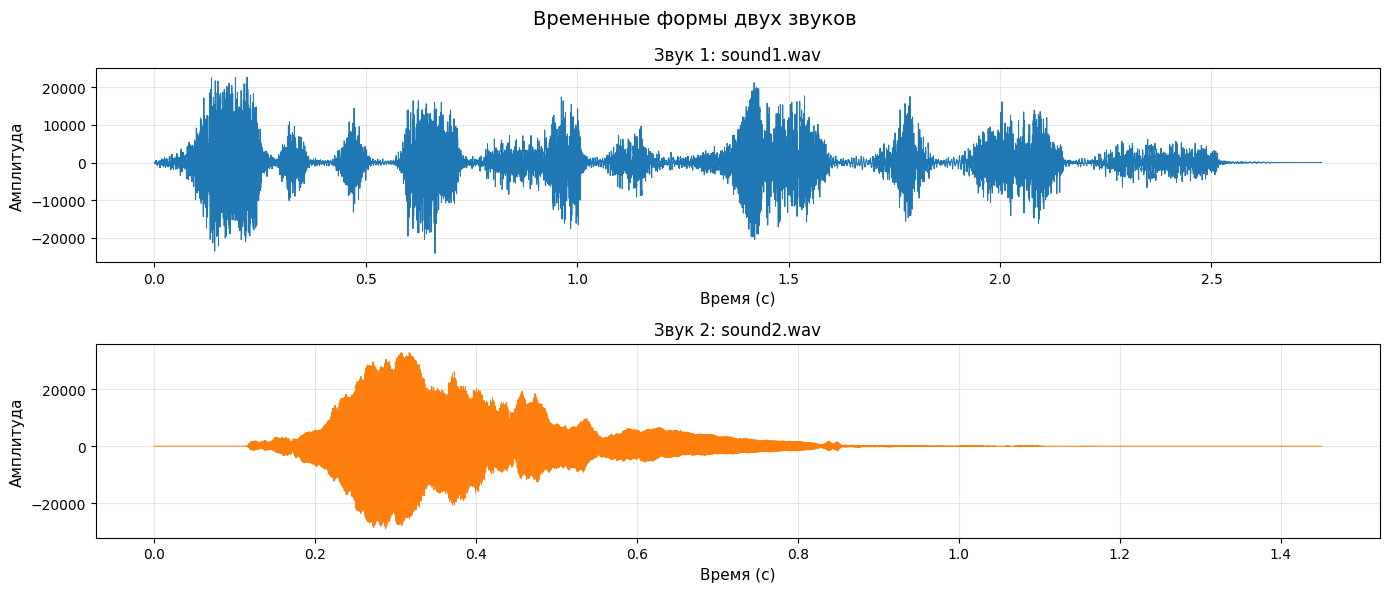

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

plot_waveform(time1, data1, f'Звук 1: {FILE1}', axes[0], color='tab:blue')
plot_waveform(time2, data2, f'Звук 2: {FILE2}', axes[1], color='tab:orange')

plt.suptitle('Временные формы двух звуков', fontsize=14)
plt.tight_layout()
plt.show()

Ну собственно 1 звук это у меня орк о чем-то ращговаривает, а второй это мяукнул кот)

#### 3. Конвертация стерео в моно (оно тут не нужно, тк мои звуки уже в моно)

Звук 1 моно: форма=(121738,), sr=44100 Гц
Звук 2 моно: форма=(63983,), sr=44100 Гц


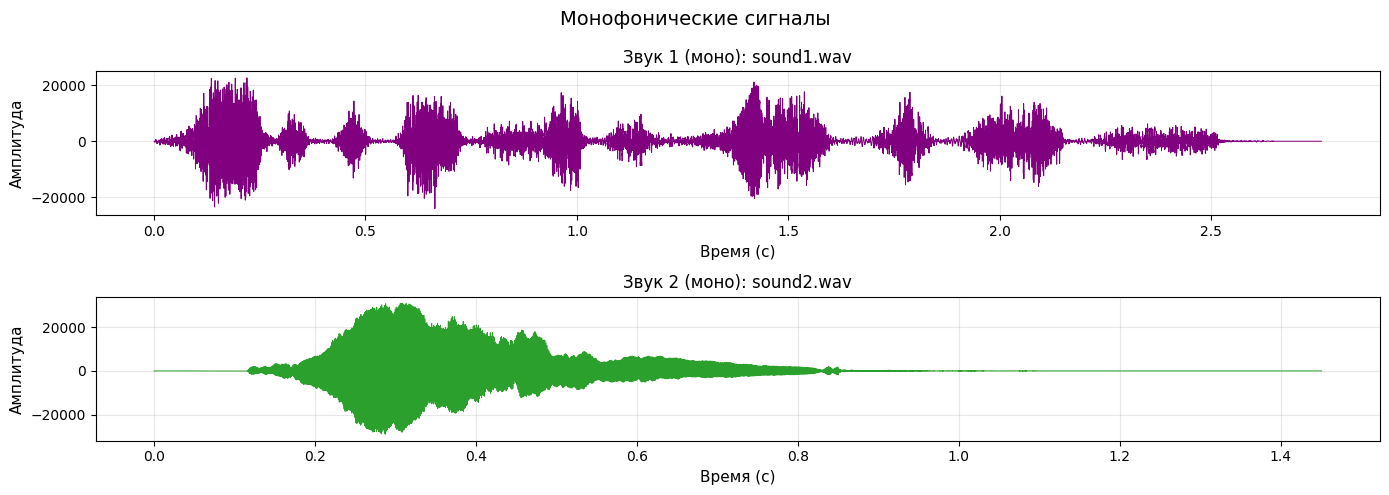

In [6]:
# Конвертируем оба файла в моно
sr1_m, data1_m = to_mono_pydub(FILE1, 'mono1.wav')
sr2_m, data2_m = to_mono_pydub(FILE2, 'mono2.wav')

print(f"Звук 1 моно: форма={data1_m.shape}, sr={sr1_m} Гц")
print(f"Звук 2 моно: форма={data2_m.shape}, sr={sr2_m} Гц")

# Пересчитываем временные оси для моно
time1_m = np.linspace(0, len(data1_m)/sr1_m, len(data1_m))
time2_m = np.linspace(0, len(data2_m)/sr2_m, len(data2_m))

fig, axes = plt.subplots(2, 1, figsize=(14, 5))
plot_waveform(time1_m, data1_m, f'Звук 1 (моно): {FILE1}', axes[0], color='purple')
plot_waveform(time2_m, data2_m, f'Звук 2 (моно): {FILE2}', axes[1], color='tab:green')
plt.suptitle('Монофонические сигналы', fontsize=14)
plt.tight_layout()
plt.show()


можно вставить другие стерео звуки и посмотреть

In [7]:
import sounddevice as sd
import ipywidgets as widgets
from IPython.display import display, Audio

for name, data, sr in [(FILE1, data1_m, sr1_m), (FILE2, data2_m, sr2_m)]:
    print(f" {name}")
    display(Audio(data.astype(np.float32) / np.max(np.abs(data)), rate=sr))


 sound1.wav


 sound2.wav


## Упражнение 2

#### 1. Быстрое преобразование Фурье

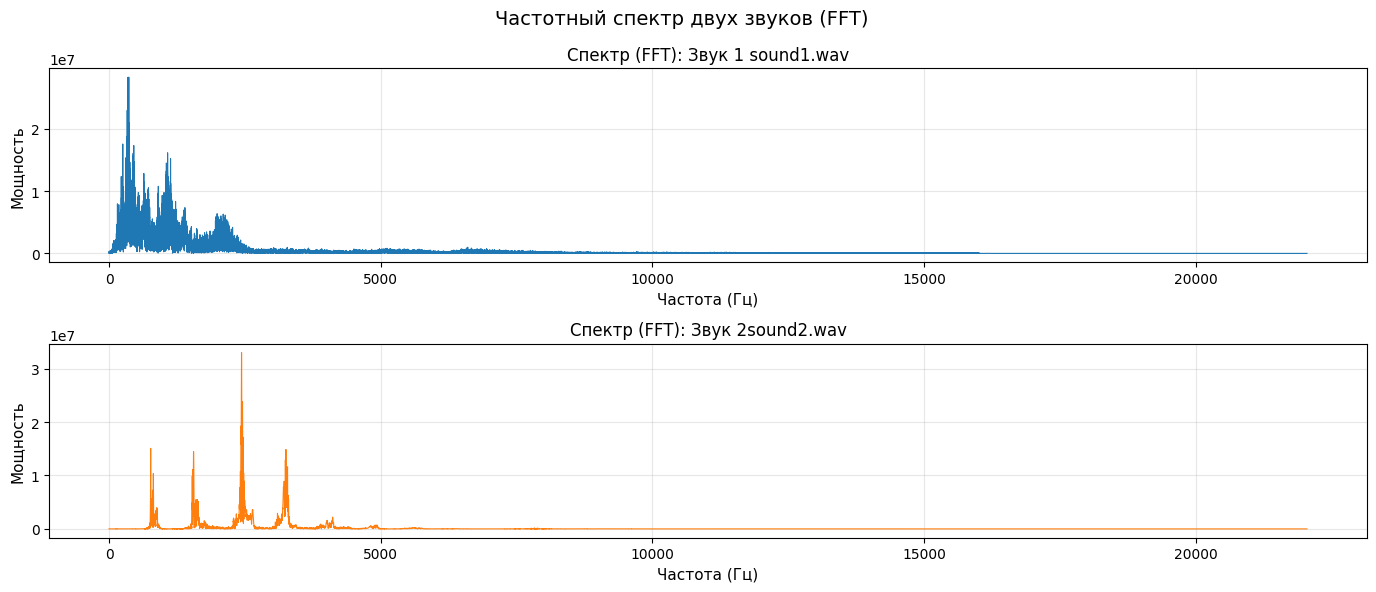

Частота Найквиста (Звук 1): 22050 Гц
Частота Найквиста (Звук 2): 22050 Гц
Доминирующая частота (Звук 1): 363.3 Гц
Доминирующая частота (Звук 2): 2438.6 Гц


In [8]:
xf1, yf1 = compute_spectrum(data1_m, sr1_m)
xf2, yf2 = compute_spectrum(data2_m, sr2_m)

fig, axes = plt.subplots(2, 1, figsize=(14, 6))

axes[0].plot(xf1[:len(xf1)//2], np.abs(yf1[:len(yf1)//2]), color='tab:blue', lw=0.8)
axes[0].set_title(f'Спектр (FFT): Звук 1 {FILE1}', fontsize=12)
axes[0].set_xlabel('Частота (Гц)', fontsize=11)
axes[0].set_ylabel('Мощность', fontsize=11)
axes[0].grid(alpha=0.3)

axes[1].plot(xf2[:len(xf2)//2], np.abs(yf2[:len(yf2)//2]), color='tab:orange', lw=0.8)
axes[1].set_title(f'Спектр (FFT): Звук 2{FILE2}', fontsize=12)
axes[1].set_xlabel('Частота (Гц)', fontsize=11)
axes[1].set_ylabel('Мощность', fontsize=11)
axes[1].grid(alpha=0.3)

plt.suptitle('Частотный спектр двух звуков (FFT)', fontsize=14)
plt.tight_layout()
plt.show()

# Частота Найквиста
print(f"Частота Найквиста (Звук 1): {sr1_m // 2} Гц")
print(f"Частота Найквиста (Звук 2): {sr2_m // 2} Гц")


idx1 = np.argmax(np.abs(yf1[:len(yf1)//2]))
idx2 = np.argmax(np.abs(yf2[:len(yf2)//2]))
print(f"Доминирующая частота (Звук 1): {xf1[idx1]:.1f} Гц")
print(f"Доминирующая частота (Звук 2): {xf2[idx2]:.1f} Гц")


По 1 звуку: Спектр показывает широкополосный шумоподобный характер Доминирующая частота (Звук 1): 363.3 Гц, Такой спектр типичен для речи (разговор орка)

По 2 звуку: Спектр имеет ярко выраженные дискретные пики на нескольких гармониках, Доминанта 2439 Гц 

#### 2. Односторонний спектр

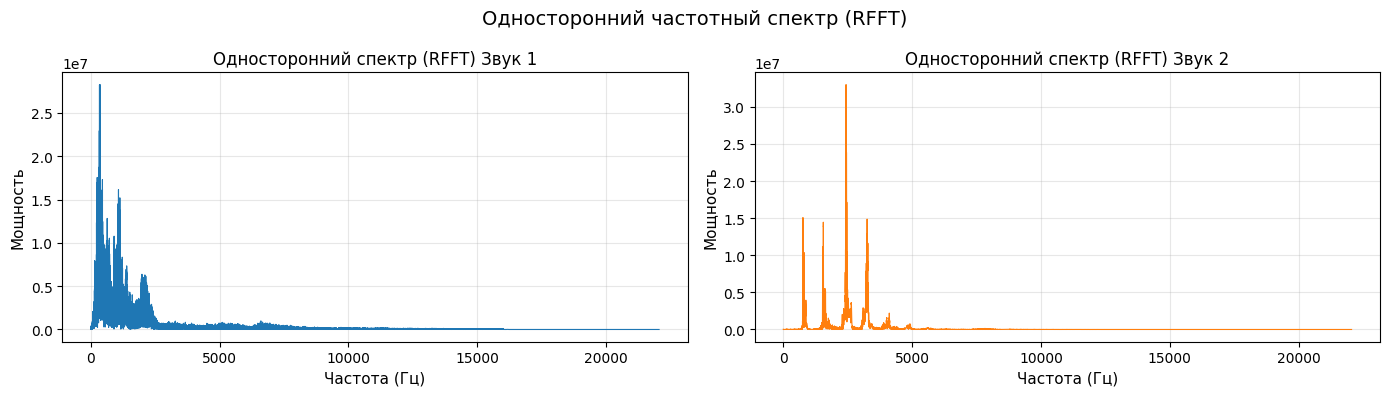

In [9]:
rxf1, ryf1 = compute_rspectrum(data1_m, sr1_m)
rxf2, ryf2 = compute_rspectrum(data2_m, sr2_m)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(rxf1, np.abs(ryf1), color='tab:blue', lw=0.8)
axes[0].set_title(f'Односторонний спектр (RFFT) Звук 1', fontsize=12)
axes[0].set_xlabel('Частота (Гц)', fontsize=11)
axes[0].set_ylabel('Мощность', fontsize=11)
axes[0].grid(alpha=0.3)

axes[1].plot(rxf2, np.abs(ryf2), color='tab:orange', lw=0.8)
axes[1].set_title(f'Односторонний спектр (RFFT) Звук 2', fontsize=12)
axes[1].set_xlabel('Частота (Гц)', fontsize=11)
axes[1].set_ylabel('Мощность', fontsize=11)
axes[1].grid(alpha=0.3)

plt.suptitle('Односторонний частотный спектр (RFFT)', fontsize=14)
plt.tight_layout()
plt.show()


Оба сигнала низкочастотны, вся значимая энергия лежит ниже 5-6 кГц

#### 3. Кепстр

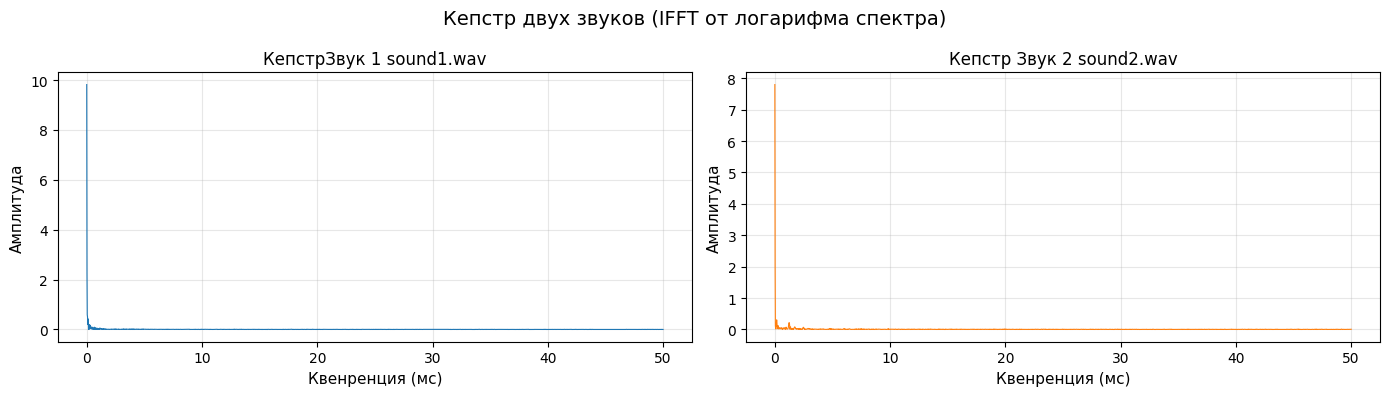

In [10]:
q1, cep1 = compute_cepstrum(data1_m, sr1_m)
q2, cep2 = compute_cepstrum(data2_m, sr2_m)

max_q = 0.05  #cекунды

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

mask1 = q1 <= max_q
axes[0].plot(q1[mask1] * 1000, cep1[mask1], color='tab:blue', lw=0.8)
axes[0].set_title(f'КепстрЗвук 1 {FILE1}', fontsize=12)
axes[0].set_xlabel('Квенренция (мс)', fontsize=11)
axes[0].set_ylabel('Амплитуда', fontsize=11)
axes[0].grid(alpha=0.3)

mask2 = q2 <= max_q
axes[1].plot(q2[mask2] * 1000, cep2[mask2], color='tab:orange', lw=0.8)
axes[1].set_title(f'Кепстр Звук 2 {FILE2}', fontsize=12)
axes[1].set_xlabel('Квенренция (мс)', fontsize=11)
axes[1].set_ylabel('Амплитуда', fontsize=11)
axes[1].grid(alpha=0.3)

plt.suptitle('Кепстр двух звуков (IFFT от логарифма спектра)', fontsize=14)
plt.tight_layout()
plt.show()


У обоих звуков наблюдается мощный нулевой пик. В 1 звуке после 0 практически нет пиков, во 2 слабые, но заметные вторичные пики в области 1–2 мс после нулевого

#### 4. MFCC

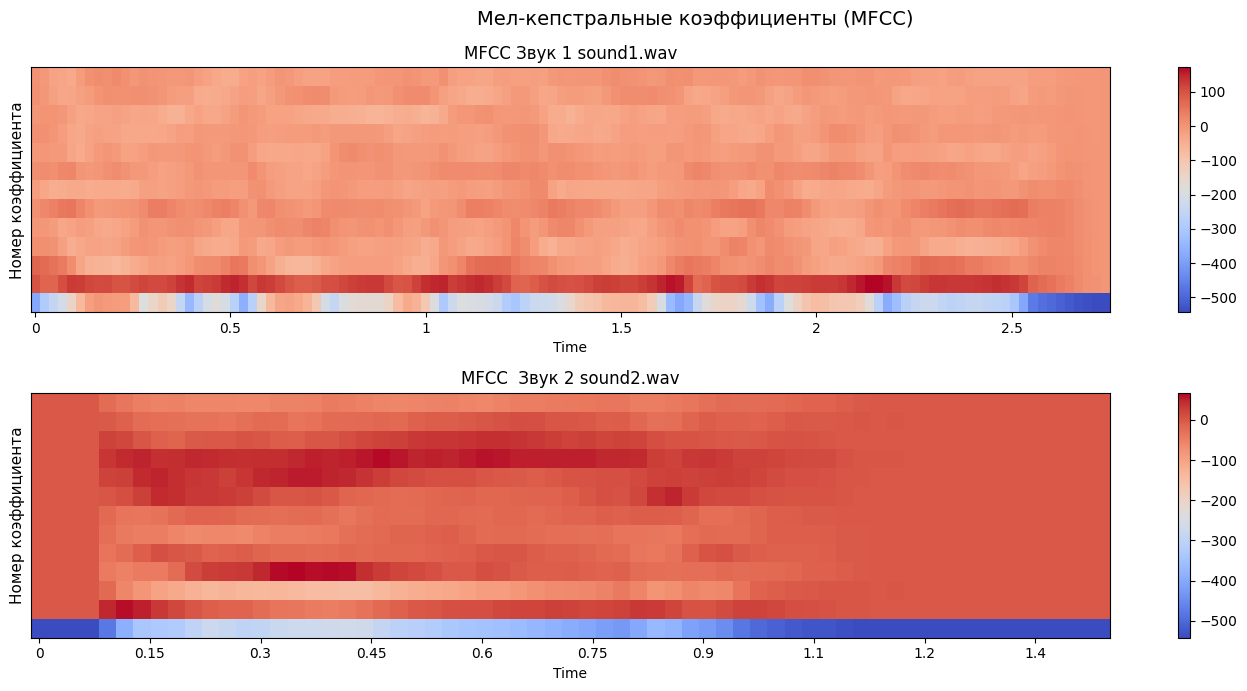

Форма MFCC (Звук 1): (13, 119)  → 13 коэффициентов × 119 временных фреймов
Форма MFCC (Звук 2): (13, 63)  → 13 коэффициентов × 63 временных фреймов


In [11]:
#Загружаем через librosa для вычисления MFCC
y1, sr1_lr = librosa.load(FILE1)
y2, sr2_lr = librosa.load(FILE2)

n_mfcc = 13  #стандартное число коэффициентов

mfccs1 = librosa.feature.mfcc(y=y1, sr=sr1_lr, n_mfcc=n_mfcc)
mfccs2 = librosa.feature.mfcc(y=y2, sr=sr2_lr, n_mfcc=n_mfcc)

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

img1 = librosa.display.specshow(mfccs1, x_axis='time', sr=sr1_lr, ax=axes[0], cmap='coolwarm')
fig.colorbar(img1, ax=axes[0])
axes[0].set_title(f'MFCC Звук 1 {FILE1}', fontsize=12)
axes[0].set_ylabel('Номер коэффициента', fontsize=11)

img2 = librosa.display.specshow(mfccs2, x_axis='time', sr=sr2_lr, ax=axes[1], cmap='coolwarm')
fig.colorbar(img2, ax=axes[1])
axes[1].set_title(f'MFCC  Звук 2 {FILE2}', fontsize=12)
axes[1].set_ylabel('Номер коэффициента', fontsize=11)

plt.suptitle('Мел-кепстральные коэффициенты (MFCC)', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Форма MFCC (Звук 1): {mfccs1.shape}  → {n_mfcc} коэффициентов × {mfccs1.shape[1]} временных фреймов")
print(f"Форма MFCC (Звук 2): {mfccs2.shape}  → {n_mfcc} коэффициентов × {mfccs2.shape[1]} временных фреймов")


У обоих звуков нижняя строка отображается насыщенным тёмно-синим цветом (означает высокую суммарную энергию сигнала на протяжении всей записи)

Звук 1 он нестабильный, переменный. видны чередующиеся красные и голубые блоки, особенно в средних коэффициентах. Это говорит о том, что спектральная огибающая нестабильна, тембр и формантная структура сигнала постоянно изменяются.



#### 5. Средние MFCC

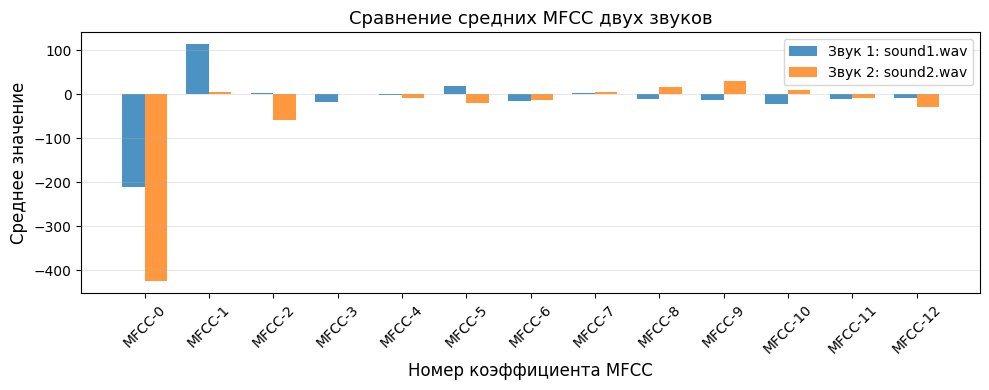

Средние MFCC (Звук 1): [-210.23  114.05    3.79  -16.19   -2.52   19.17  -14.69    3.56  -11.22
  -12.42  -21.89  -11.39   -8.4 ]
Средние MFCC (Звук 2): [-424.07    4.88  -57.48    1.39   -8.44  -20.45  -12.56    4.7    15.84
   29.42    8.97   -8.99  -29.59]
L2 расстояние между MFCC векторами: 259.240


In [12]:
mean_mfcc1 = np.mean(mfccs1, axis=1)
mean_mfcc2 = np.mean(mfccs2, axis=1)

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(n_mfcc)
width = 0.35

bars1 = ax.bar(x - width/2, mean_mfcc1, width, label=f'Звук 1: {FILE1}', color='tab:blue', alpha=0.8)
bars2 = ax.bar(x + width/2, mean_mfcc2, width, label=f'Звук 2: {FILE2}', color='tab:orange', alpha=0.8)

ax.set_xlabel('Номер коэффициента MFCC', fontsize=12)
ax.set_ylabel('Среднее значение', fontsize=12)
ax.set_title('Сравнение средних MFCC двух звуков', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels([f'MFCC-{i}' for i in range(n_mfcc)], rotation=45)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Средние MFCC (Звук 1):", np.round(mean_mfcc1, 2))
print("Средние MFCC (Звук 2):", np.round(mean_mfcc2, 2))
print(f"L2 расстояние между MFCC векторами: {np.linalg.norm(mean_mfcc1 - mean_mfcc2):.3f}")


Расстояние между MFCC векторами получилось большим, это значит, что два звука кардинально отличаются по тембру

#### 6. GFCC

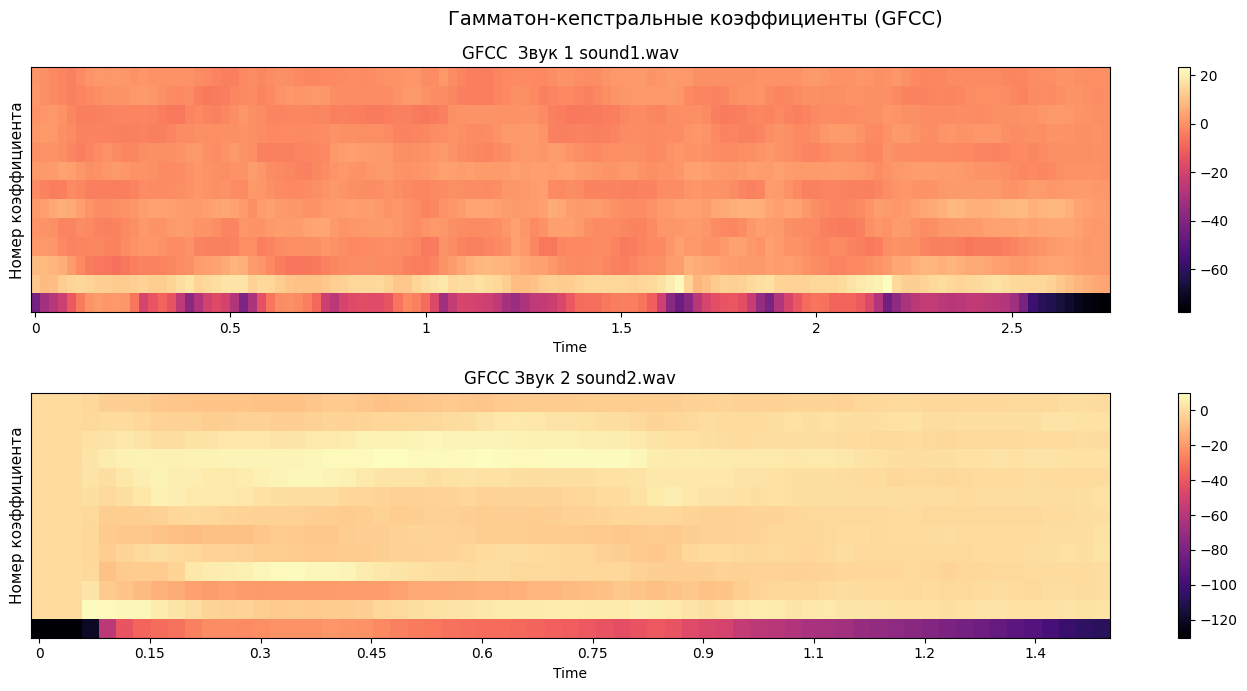

In [13]:
def compute_gfcc(y, sr, n_filters=32, n_cepstral=13):
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_filters, fmax=sr//2)
    # Логарифмическое сжатие амплитуды
    log_mel = np.log(mel_spec + 1e-10)
    # DCT для получения кепстральных коэффициентов
    from scipy.fft import dct as scipy_dct
    gfcc = scipy_dct(log_mel, type=2, axis=0, norm='ortho')[:n_cepstral]
    return gfcc

gfcc1 = compute_gfcc(y1, sr1_lr)
gfcc2 = compute_gfcc(y2, sr2_lr)

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

img1 = librosa.display.specshow(gfcc1, x_axis='time', sr=sr1_lr, ax=axes[0], cmap='magma')
fig.colorbar(img1, ax=axes[0])
axes[0].set_title(f'GFCC  Звук 1 {FILE1}', fontsize=12)
axes[0].set_ylabel('Номер коэффициента', fontsize=11)

img2 = librosa.display.specshow(gfcc2, x_axis='time', sr=sr2_lr, ax=axes[1], cmap='magma')
fig.colorbar(img2, ax=axes[1])
axes[1].set_title(f'GFCC Звук 2 {FILE2}', fontsize=12)
axes[1].set_ylabel('Номер коэффициента', fontsize=11)

plt.suptitle('Гамматон-кепстральные коэффициенты (GFCC)', fontsize=14)
plt.tight_layout()
plt.show()


Звук 1 нестабилен во времени (пятнистая текстура), Звук 2 стабилен (однородный фон)

## Упражнение 3

#### 1. Спектрограмма через scipy.signal

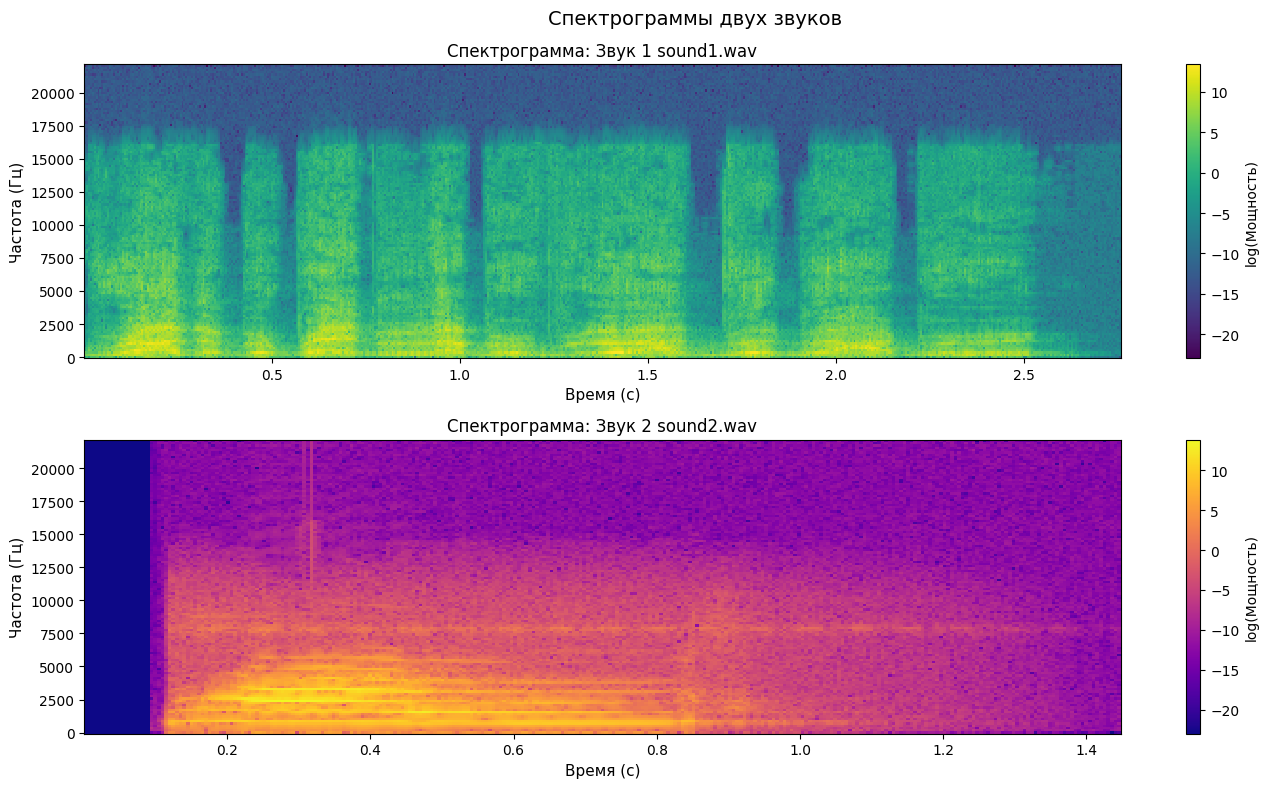

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for ax, d, sr, title, cmap in zip(
    axes,
    [data1_m, data2_m],
    [sr1_m, sr2_m],
    [f'Спектрограмма: Звук 1 {FILE1}', f'Спектрограмма: Звук 2 {FILE2}'],
    ['viridis', 'plasma']
):
    fr, tm, spgram = signal.spectrogram(d.astype(float), sr)
    lspg = np.log(spgram + 1e-10)
    pcm = ax.pcolormesh(tm, fr, lspg, shading='auto', cmap=cmap)
    fig.colorbar(pcm, ax=ax, label='log(Мощность)')
    ax.set_ylabel('Частота (Гц)', fontsize=11)
    ax.set_xlabel('Время (с)', fontsize=11)
    ax.set_title(title, fontsize=12)

plt.suptitle('Спектрограммы двух звуков', fontsize=14)
plt.tight_layout()
plt.show()


Звук 1 динамичный широкополосный сигнал. Хорошо видны вертикальные тёмные провалы (8–10 штук)это регулярные паузы или смычки, характерные для ударных или импульсных звуков (шаги, хлопки, слоги речи). 

Звук 2 стационарный тональный сигнал с чёткой структурой. Видны 3–4 яркие горизонтальные полосы в диапазоне 0–5 кГц, это гармоники постоянного тона



#### 2. Мел-спектрограмма

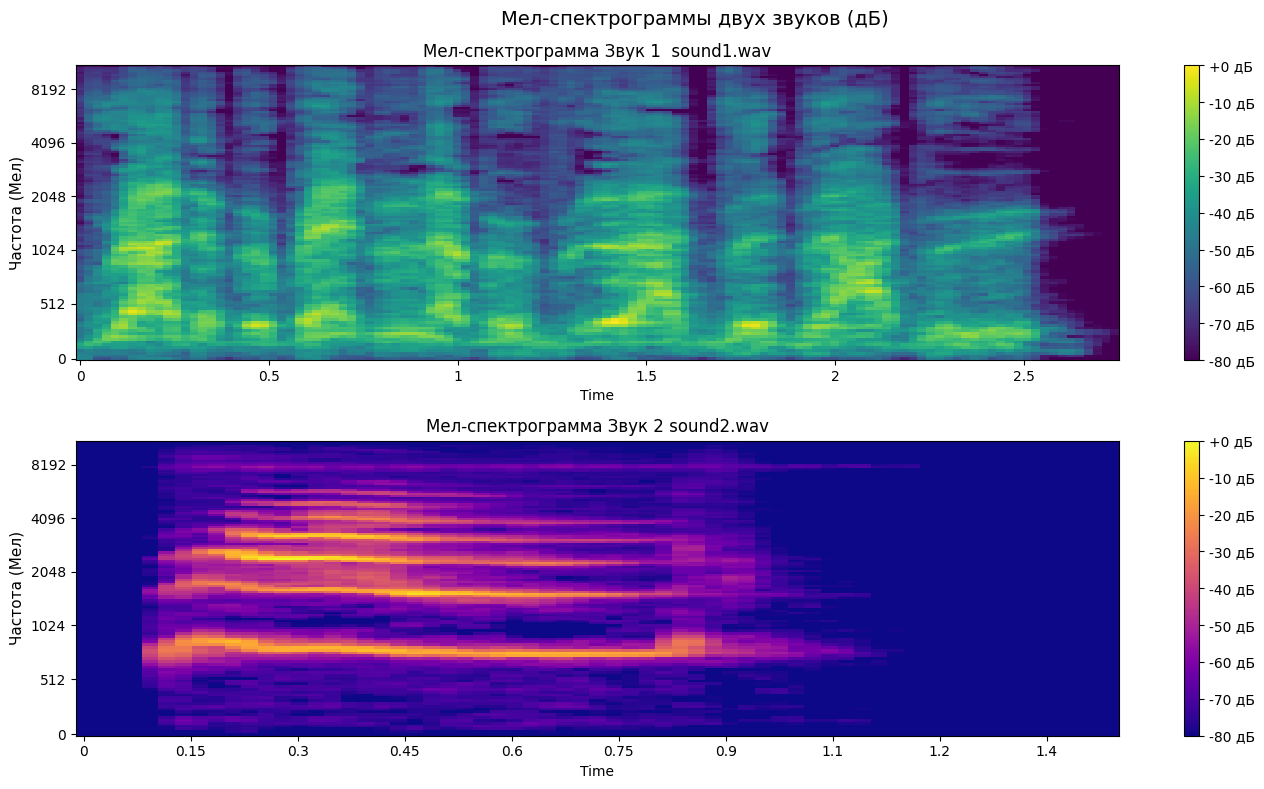

In [16]:
S1 = librosa.feature.melspectrogram(y=y1, sr=sr1_lr, n_mels=128, fmax=sr1_lr//2)
S2 = librosa.feature.melspectrogram(y=y2, sr=sr2_lr, n_mels=128, fmax=sr2_lr//2)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

img1 = librosa.display.specshow(
    librosa.power_to_db(S1, ref=np.max),
    x_axis='time', y_axis='mel', fmax=sr1_lr//2, sr=sr1_lr, ax=axes[0], cmap='viridis'
)
fig.colorbar(img1, ax=axes[0], format='%+2.0f дБ')
axes[0].set_title(f'Мел-спектрограмма Звук 1  {FILE1}', fontsize=12)
axes[0].set_ylabel('Частота (Мел)', fontsize=11)

img2 = librosa.display.specshow(
    librosa.power_to_db(S2, ref=np.max),
    x_axis='time', y_axis='mel', fmax=sr2_lr//2, sr=sr2_lr, ax=axes[1], cmap='plasma'
)
fig.colorbar(img2, ax=axes[1], format='%+2.0f дБ')
axes[1].set_title(f'Мел-спектрограмма Звук 2 {FILE2}', fontsize=12)
axes[1].set_ylabel('Частота (Мел)', fontsize=11)

plt.suptitle('Мел-спектрограммы двух звуков (дБ)', fontsize=14)
plt.tight_layout()
plt.show()


#### 3. Совмещённый график

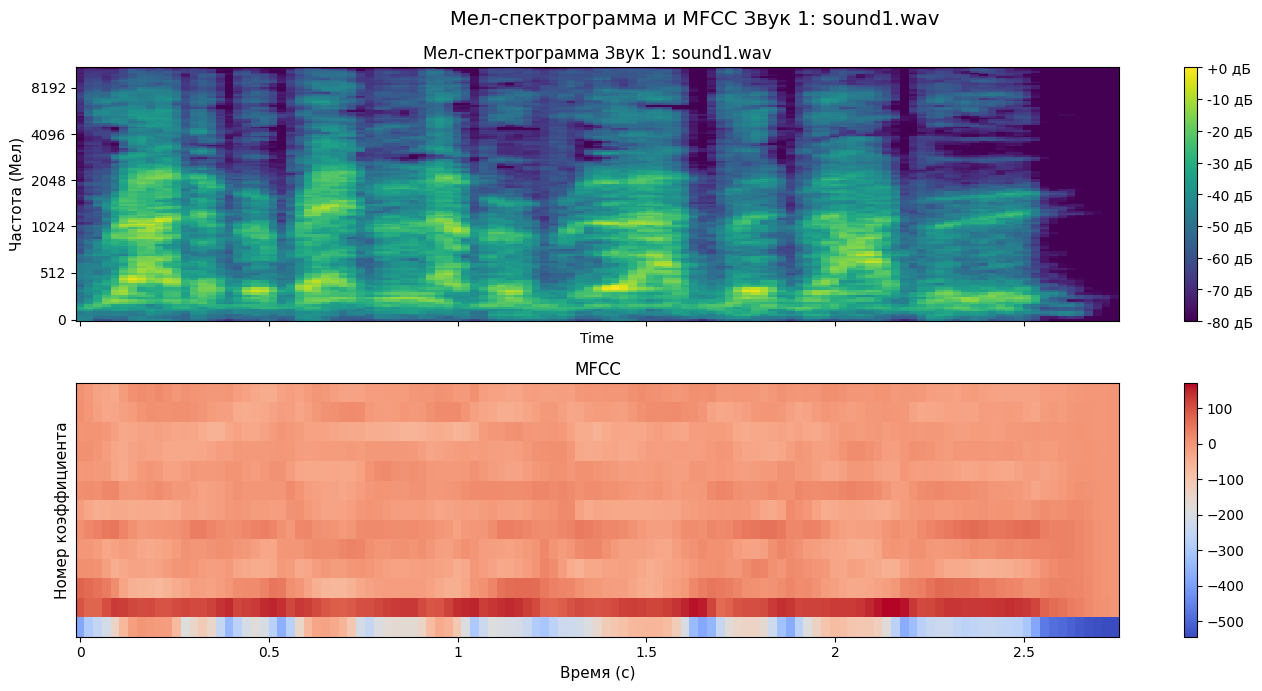

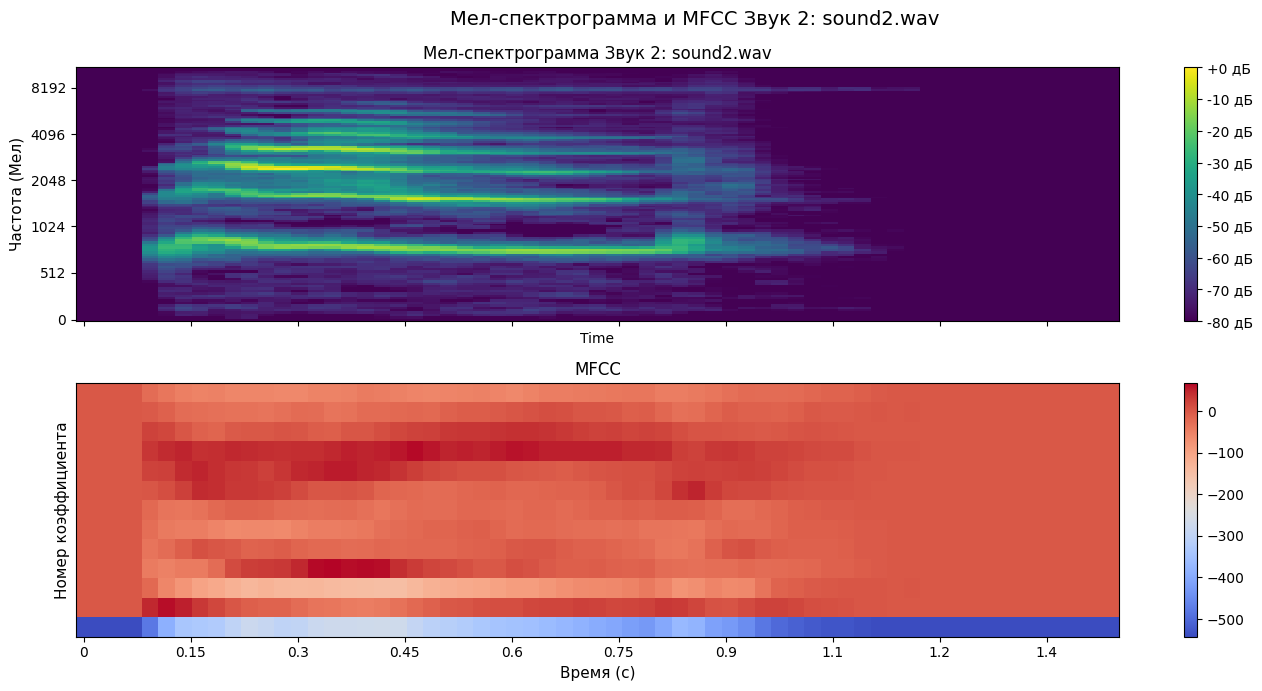

In [17]:
for y, sr, S, mfccs, title in [
    (y1, sr1_lr, S1, mfccs1, f'Звук 1: {FILE1}'),
    (y2, sr2_lr, S2, mfccs2, f'Звук 2: {FILE2}')
]:
    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

    img_mel = librosa.display.specshow(
        librosa.power_to_db(S, ref=np.max),
        x_axis='time', y_axis='mel', sr=sr, ax=axes[0], cmap='viridis'
    )
    fig.colorbar(img_mel, ax=axes[0], format='%+2.0f дБ')
    axes[0].set_title(f'Мел-спектрограмма {title}', fontsize=12)
    axes[0].set_ylabel('Частота (Мел)', fontsize=11)

    img_mfcc = librosa.display.specshow(mfccs, x_axis='time', sr=sr, ax=axes[1], cmap='coolwarm')
    fig.colorbar(img_mfcc, ax=axes[1])
    axes[1].set_title('MFCC', fontsize=12)
    axes[1].set_ylabel('Номер коэффициента', fontsize=11)
    axes[1].set_xlabel('Время (с)', fontsize=11)

    plt.suptitle(f'Мел-спектрограмма и MFCC {title}', fontsize=14)
    plt.tight_layout()
    plt.show()


Звук 1 диффузная корреляция. Вертикальные тёмные провалы на мел-спектрограмме (паузы сигнала) синхронны с флуктуациями нижней строки MFCC-0 в моменты пауз энергия падает, MFCC-0 уходит в синий. Средние коэффициенты (MFCC 2-8) нестабильны на протяжении всей записи, это отражает постоянно меняющуюся спектральную огибающую

Звук 2 чёткая корреляция. Яркие горизонтальные полосы на мел-спектрограмме точно соответствуют стабильному красному блоку в MFCC, пока гармоники горят ярко коэффициенты ровные

## Упражнение 4

1. Сравнение спектров на одном графике

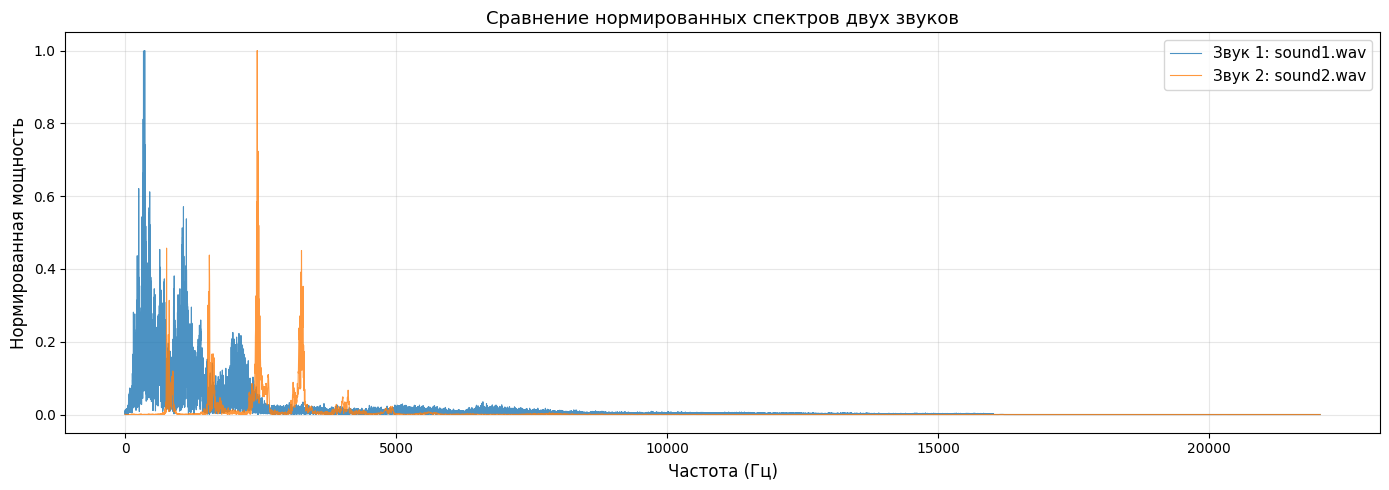

In [18]:
fig, ax = plt.subplots(figsize=(14, 5))

# Нормируем для удобства сравнения
abs_yf1 = np.abs(yf1[:len(yf1)//2])
abs_yf2 = np.abs(yf2[:len(yf2)//2])
abs_yf1_norm = abs_yf1 / abs_yf1.max()
abs_yf2_norm = abs_yf2 / abs_yf2.max()

ax.plot(xf1[:len(xf1)//2], abs_yf1_norm, color='tab:blue', lw=0.8, alpha=0.8, label=f'Звук 1: {FILE1}')
ax.plot(xf2[:len(xf2)//2], abs_yf2_norm, color='tab:orange', lw=0.8, alpha=0.8, label=f'Звук 2: {FILE2}')
ax.set_xlabel('Частота (Гц)', fontsize=12)
ax.set_ylabel('Нормированная мощность', fontsize=12)
ax.set_title('Сравнение нормированных спектров двух звуков', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Зона совпадения (0–500 Гц) Зона расхождения (500–5000 Гц) здесь спектры кардинально разные

#### 2. Сводная таблица числовых характеристик

In [22]:
def spectral_centroid(freqs, magnitudes):
    return np.sum(freqs * magnitudes) / (np.sum(magnitudes) + 1e-10)

def spectral_bandwidth(freqs, magnitudes, centroid):
    return np.sqrt(np.sum(((freqs - centroid)**2) * magnitudes) / (np.sum(magnitudes) + 1e-10))

abs1 = np.abs(yf1[:len(yf1)//2])
abs2 = np.abs(yf2[:len(yf2)//2])
f1_pos = xf1[:len(xf1)//2]
f2_pos = xf2[:len(xf2)//2]

sc1 = spectral_centroid(f1_pos, abs1)
sc2 = spectral_centroid(f2_pos, abs2)
sb1 = spectral_bandwidth(f1_pos, abs1, sc1)
sb2 = spectral_bandwidth(f2_pos, abs2, sc2)

idx_dom1 = np.argmax(abs1)
idx_dom2 = np.argmax(abs2)


print(f"{'Характеристика':<35} {'Звук 1':>10} {'Звук 2':>10}")
print("=" * 60)
print(f"{'Частота дискретизации (Гц)':<35} {sr1_m:>10} {sr2_m:>10}")
print(f"{'Длительность (с)':<35} {dur1:>10.3f} {dur2:>10.3f}")
print(f"{'Частота Найквиста (Гц)':<35} {sr1_m//2:>10} {sr2_m//2:>10}")
print(f"{'Доминирующая частота (Гц)':<35} {f1_pos[idx_dom1]:>10.1f} {f2_pos[idx_dom2]:>10.1f}")
print(f"{'Спектральный центроид (Гц)':<35} {sc1:>10.1f} {sc2:>10.1f}")
print(f"{'Спектральная ширина (Гц)':<35} {sb1:>10.1f} {sb2:>10.1f}")
print(f"{'Среднее MFCC-0 (энергия)':<35} {mean_mfcc1[0]:>10.2f} {mean_mfcc2[0]:>10.2f}")
print(f"{'L2-расстояние MFCC-векторов':<35} {np.linalg.norm(mean_mfcc1 - mean_mfcc2):>10.3f}")


Характеристика                          Звук 1     Звук 2
Частота дискретизации (Гц)               44100      44100
Длительность (с)                         2.760      1.451
Частота Найквиста (Гц)                   22050      22050
Доминирующая частота (Гц)                363.3     2438.6
Спектральный центроид (Гц)              2092.6     2585.4
Спектральная ширина (Гц)                2706.7     1181.0
Среднее MFCC-0 (энергия)               -210.23    -424.07
L2-расстояние MFCC-векторов            259.240


Звук 2 имеет более высокий спектральный центроид (ярче), 2585 Гц против 2093 Гц у Звука 1

Звук 1 значительно шире спектральная ширина 2707 Гц против 1181 Гц у Звука 2 более чем вдвое

L2-расстояние 259.24 очень большое значение

MFCC наилучший метод для автоматической классификации